# Assignment 5
## Naïve Bayes Text Classifier

### Name : Yogesh Pawar

## Part 1 — Theory (Write in Markdown) 


#### 1. What is Bayes’ Theorem? (words + formula) 


Bayes’ Theorem is a probability theorem used to determine the probability of an event based on prior knowledge and new evidence. It forms the foundation of the Naive Bayes algorithm used in machine learning for classification tasks such as spam detection, sentiment analysis, and document categorization.

Formula:                 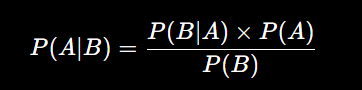




where P(A∣B) is the posterior probability, P(B∣A) is the likelihood, P(A) is the prior probability, and P(B) is the evidence.

#### 2. What does “naïve” mean in Naïve Bayes? 


The term "Naïve" in Naïve Bayes refers to the assumption that all features are independent of each other given the class label. The algorithm treats each feature as contributing independently to the probability of a class. Although this assumption is often unrealistic in real-world data, it simplifies computation and allows Naïve Bayes to perform efficiently and effectively in many classification tasks.

#### 3. Why does Naïve Bayes still work well? 


Naïve Bayes works well despite its independence assumption because classification only requires identifying the most probable class, not estimating perfectly accurate probabilities. The algorithm efficiently combines information from many features, handles high-dimensional data well, trains quickly, and performs effectively even with limited training data. As a result, Naïve Bayes often achieves strong performance in applications such as spam detection, sentiment analysis, and text classification.

#### 4. What is Laplace smoothing? Why is it needed? 


Laplace Smoothing is a technique used in Naïve Bayes to avoid zero probabilities for unseen words or features. It works by adding a small value (usually 1) to every feature count before calculating probabilities. This ensures that no probability becomes zero, allowing the model to make predictions even when it encounters words that were not present in the training data. Laplace Smoothing improves the robustness and generalization of the Naïve Bayes classifier.

Formula:   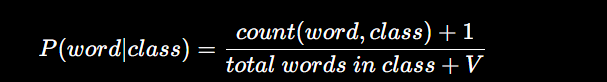


where V is the vocabulary size.

#### 5. Difference between: 
    

**MultinomialNB** is designed for count-based features such as word frequencies and TF-IDF scores, making it ideal for text classification.

**GaussianNB** is used for continuous numerical data and assumes features follow a normal distribution. 

**BernoulliNB** is designed for binary features where values represent the presence or absence of a feature. For text classification tasks

#### Which one is best for text and why?

MultinomialNB is generally the best choice because it effectively uses word frequency information and performs well on high-dimensional sparse text data.

## Part 2 — Load & Explore 
● Load dataset 
● Show shape & first rows 
● Plot class distribution 
● Check if data is balanced

In [1]:
# Data Manipulation
import pandas as pd

# Numerical Computation
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB,BernoulliNB, ComplementNB
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix

from sklearn.metrics import accuracy_score, f1_score


In [3]:
# Load Dataset
df = pd.read_csv(r"final_dataset.csv")

In [4]:
# shape of dataset
df.shape

(60, 3)

In [5]:
# first rows
df.head()

,Text,Label,clean_Text
0,Artificial intelligence(AI) is the capability ...,AI,artificial intelligence ai is the capability o...
1,Machine learning(ML) is a field of study inart...,AI,machine learning ml is a field of study in art...
2,"Inmachine learning,deep learning(DL) focuses o...",AI,in machine learning deep learning dl focuses o...
3,Aneural networkis a group of interconnected un...,AI,a neural network is a group of interconnected ...
4,Natural language processing(NLP) is the proces...,AI,natural language processing nlp is the process...


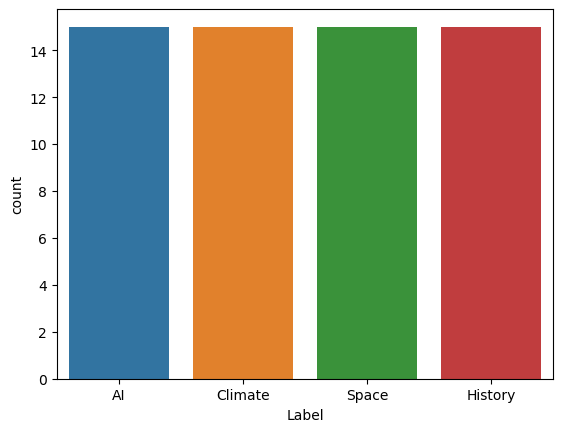

In [6]:
# ● Plot class distribution 
sns.countplot(x="Label", data=df,hue='Label')
plt.show()

In [7]:
# Check data is balanced 
df.Label.value_counts()

Label
AI         15
Climate    15
Space      15
History    15
Name: count, dtype: int64

# Part 3 — Model Building 


In [8]:
# Select target variable
y = df["Label"]
y.shape

(60,)

In [9]:
# Select input variables
X = df["clean_Text"]
X.shape

(60,)

In [10]:
# plit data (80–20) 
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(48,)
(48,)
(12,)
(12,)


In [11]:
# Create Pipeline
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('nb', MultinomialNB())
])


In [12]:
# Train model
pipeline.fit(X_train, y_train)


Pipeline(steps=[('tfidf', TfidfVectorizer()), ('nb', MultinomialNB())])

In [13]:
# Make predictions
y_pred = pipeline.predict(X_test)
y_pred

array(['Climate', 'Climate', 'Climate', 'Climate', 'Climate', 'Climate',
       'Space', 'Climate', 'Climate', 'Climate', 'Climate', 'Climate'],
      dtype='<U7')

In [14]:
# Display predictions
for text, actual, pred in zip(X_test[:5], y_test[:5], y_pred[:5]):
    print(f"Actual: {actual}")
    print(f"Predicted: {pred}\n")
    

Actual: AI
Predicted: Climate

Actual: AI
Predicted: Climate

Actual: Space
Predicted: Climate

Actual: History
Predicted: Climate

Actual: AI
Predicted: Climate



# Part 4 — Evaluation

In [15]:
print("Accuracy:")
print(accuracy_score(y_test, y_pred))

print("\nconfusion Matrix:")
print(confusion_matrix(y_test,y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy:
0.08333333333333333

confusion Matrix:
[[0 4 0 0]
 [0 0 0 0]
 [0 6 0 0]
 [0 1 0 1]]

Classification Report:
              precision    recall  f1-score   support

          AI       0.00      0.00      0.00         4
     Climate       0.00      0.00      0.00         0
     History       0.00      0.00      0.00         6
       Space       1.00      0.50      0.67         2

    accuracy                           0.08        12
   macro avg       0.25      0.12      0.17        12
weighted avg       0.17      0.08      0.11        12



# Part 5 — Model Understanding 
    ● Top 20 words per class 
    ● Show: 
        ○ 5 most confident predictions 
        ○ 5 least confident predictions 
    ● Try smoothing (alpha=1.0 vs 0.1)

##### ● Top 20 words per class

In [16]:
vectorizer = CountVectorizer(ngram_range=(1, 1), stop_words='english',max_features = 50000)
X_train_Count = vectorizer.fit_transform(X_train)
words = np.array(vectorizer.get_feature_names_out())



for category in np.unique(y_train):
    idx = np.where(np.array(y_train) == category)[0]

    mean_scores = np.asarray(X_train_Count[idx].mean(axis=0)).flatten()

    top_idx = mean_scores.argsort()[-20:][::-1]

    print(f"\nCategory: {category}")
    print(words[top_idx])


Category: AI
['learning' 'data' 'neural' 'deep' 'used' 'machine' 'networks' 'ai'
 'models' 'systems' 'model' 'training' 'network' 'methods' 'based' 'style'
 'generative' 'use' 'display' 'artificial']

Category: Climate
['climate' 'energy' 'carbon' 'emissions' 'change' 'global' 'wind' 'sea'
 'solar' 'level' 'power' 'gas' 'water' 'warming' 'rise' 'methane'
 'greenhouse' 'environmental' 'countries' 'dioxide']

Category: History
['th' 'empire' 'century' 'war' 'india' 'roman' 'period' 'dynasty' 'new'
 'greek' 'early' 'renaissance' 'europe' 'states' 'union' 'mughal'
 'western' 'china' 'emperor' 'indian']

Category: Space
['space' 'nasa' 'black' 'launch' 'earth' 'mission' 'station' 'spacecraft'
 'orbit' 'moon' 'program' 'hole' 'shuttle' 'launched' 'used' 'lunar'
 'missions' 'satellite' 'landing' 'hubble']


##### ● 5 most confident predictions 

In [17]:
 
# Get prediction probabilities
y_prob = pipeline.predict_proba(X_test)

# Confidence = highest probability for each prediction
confidence = y_prob.max(axis=1)

# Create results DataFrame
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred,
    "Confidence": confidence
})

# Top 5 most confident predictions
top5 = results.sort_values(by="Confidence",ascending=False).head(5)

print(top5)

     Actual Predicted  Confidence
7   History   Climate    0.437984
10  History   Climate    0.433293
9   History   Climate    0.423350
11  History   Climate    0.418805
0        AI   Climate    0.418665


#### ● 5 least confident predictions 

In [18]:

# Get prediction probabilities
y_prob = pipeline.predict_proba(X_test)

# Confidence = highest probability for each prediction
confidence = y_prob.min(axis=1)

# Create results DataFrame
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred,
    "Confidence": confidence
})

# Top 5 most confident predictions
top5 = results.sort_values(by="Confidence",ascending=False).head(5)

print(top5)

     Actual Predicted  Confidence
5   History   Climate    0.148504
7   History   Climate    0.147923
9   History   Climate    0.142365
10  History   Climate    0.140515
3   History   Climate    0.140256


##### ● 5. Compare Smoothing (alpha=1.0 vs 0.1)


In [19]:
# Model 1 
model_alpha1 = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('nb', MultinomialNB(alpha=1.0))
])

model_alpha1.fit(X_train, y_train)
y_pred1 = model_alpha1.predict(X_test)
acc1 = accuracy_score(y_test, y_pred1)

print("Alpha=1.0 Accuracy:", acc1)

Alpha=1.0 Accuracy: 0.08333333333333333


In [20]:
# model 2
model_alpha01 = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('nb', MultinomialNB(alpha=0.1))
])

model_alpha01.fit(X_train, y_train)
y_pred2 = model_alpha01.predict(X_test)
acc2 = accuracy_score(y_test, y_pred2)

print("Alpha=0.1 Accuracy:", acc2)

Alpha=0.1 Accuracy: 0.5833333333333334


In [21]:
comparison = pd.DataFrame({
    "alpha": [1.0, 0.1],
    "accuracy": [acc1, acc2]
})

print(comparison)

   alpha  accuracy
0    1.0  0.083333
1    0.1  0.583333


## Part 6 — Model Comparison 


In [22]:
models = {
    "MultinomialNB": MultinomialNB(),
    "BernoulliNB": BernoulliNB(),
    "ComplementNB": ComplementNB()
}

results = []

for name, model in models.items():

    pipeline = Pipeline([
        ('tfidf', TfidfVectorizer()),
        ('nb', model)
    ])

    # Train
    pipeline.fit(X_train, y_train)

    # Predict
    y_pred = pipeline.predict(X_test)

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)

    f1 = f1_score(
        y_test,
        y_pred,
        average='weighted'  # suitable for multiclass
    )

    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'F1 Score': f1
    })

In [23]:
comparison_df = pd.DataFrame(results)

comparison_df = comparison_df.sort_values(
    by='F1 Score',
    ascending=False
)

print(comparison_df)

           Model  Accuracy  F1 Score
1    BernoulliNB  0.666667  0.716667
2   ComplementNB  0.583333  0.642857
0  MultinomialNB  0.083333  0.111111


BernoulliNB is the best model because it has the highest Accuracy (66.7%) and F1 Score (71.7%).
ComplementNB performed okay, but not as well as BernoulliNB.
MultinomialNB performed very poorly with only 8.3% accuracy, so it is not suitable for your data.


Conclusion
- BernoulliNB is the best choice for this dataset.

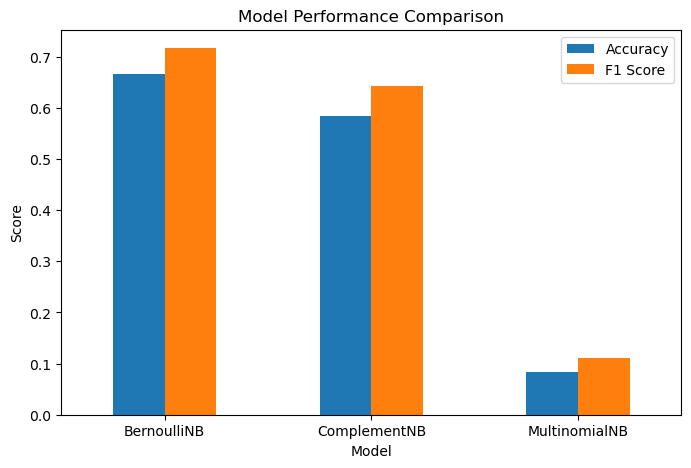

In [29]:
# Plot
comparison_df.set_index('Model').plot(kind='bar',figsize=(8, 5))

plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='best')
plt.show()